# 3 · Correlation and Diversification

*Common Core*

Why holding many assets is safer than holding one, how much safer it gets, and why the benefit is smaller than most people think.

## 1. Motivation

"Don't put all your eggs in one basket" is the oldest advice in investing. But how many baskets do you need? Is owning 40 stocks really safer than owning 10? And do bonds still protect a stock portfolio when markets crash? The answers depend on one thing: how assets move **together**. Portfolio construction, risk models and pairs trading are all built on this idea.

## 2. Intuition

Picture two assets. When one has a bad day, does the other usually have a bad day too?

- If they always move together, holding both is no safer than holding one. Their losses stack up.
- If they move independently, a bad day for one is often an ordinary day for the other. The losses partly cancel, so the portfolio is calmer than either asset alone.
- If they move in opposite directions, they hedge each other.

**Correlation** measures where a pair sits on this scale, from −1 (opposite) through 0 (independent) to +1 (together).

The catch: stocks share a common driver, the overall market. That shared part cannot be diversified away no matter how many stocks you add. Only the *stock-specific* part shrinks.

## 3. The math

For two return series $R_1, R_2$ with volatilities $\sigma_1, \sigma_2$:

- **Covariance:** $\operatorname{Cov}(R_1,R_2) = \mathbb{E}\big[(R_1-\mu_1)(R_2-\mu_2)\big]$. It is positive when the two tend to be above their averages at the same time.
- **Correlation:** covariance rescaled to lie between −1 and +1:
$$
\rho_{12} = \frac{\operatorname{Cov}(R_1,R_2)}{\sigma_1\sigma_2}.
$$

**Two-asset portfolio.** With weights $w_1 + w_2 = 1$, the portfolio return is $R_p = w_1R_1 + w_2R_2$ and its variance is
$$
\sigma_p^2 = w_1^2\sigma_1^2 + w_2^2\sigma_2^2 + 2w_1w_2\,\rho_{12}\,\sigma_1\sigma_2 .
$$
The last term is where diversification lives. When $\rho_{12} < 1$, $\sigma_p$ is *smaller* than the weighted average of $\sigma_1$ and $\sigma_2$.

**Many assets.** With a vector of weights $w$ and a **covariance matrix** $\Sigma$ (entry $i,j$ is $\operatorname{Cov}(R_i,R_j)$), the same formula becomes
$$
\sigma_p^2 = w^\top \Sigma\, w .
$$

**The diversification limit.** Hold $N$ assets with equal weights $1/N$. Let $\overline{\sigma^2}$ be their average variance and $\overline{\text{cov}}$ their average covariance between different assets. Then
$$
\sigma_p^2 = \frac{1}{N}\,\overline{\sigma^2} + \Big(1 - \frac{1}{N}\Big)\,\overline{\text{cov}} \;\xrightarrow{\;N\to\infty\;}\; \overline{\text{cov}} .
$$

<details><summary><b>Derivation (click to expand)</b></summary>

$w^\top\Sigma w = \sum_i\sum_j w_iw_j\Sigma_{ij}$. With $w_i = 1/N$ there are $N$ diagonal terms (variances) and $N(N-1)$ off-diagonal terms (covariances), each multiplied by $1/N^2$:
$$
\sigma_p^2 = \frac{1}{N^2}\Big(N\,\overline{\sigma^2} + N(N-1)\,\overline{\text{cov}}\Big) = \frac{\overline{\sigma^2}}{N} + \frac{N-1}{N}\,\overline{\text{cov}} .
$$
The first term vanishes as $N$ grows. The second does not: it is the **market risk** shared by all stocks.
</details>

## 4. Code it

### 4.1 Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

prices = pd.read_csv("../data/prices.csv", index_col="date", parse_dates=True)
meta = pd.read_csv("../data/meta.csv")

COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
plt.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 100, "axes.prop_cycle": plt.cycler(color=COLORS),
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.3, "lines.linewidth": 1.5, "font.size": 11,
})
# Diverging colour map for correlations: blue (negative) -> grey (zero) -> red (positive)
DIVERGING = LinearSegmentedColormap.from_list("div", ["#2a78d6", "#f0efec", "#e34948"])

returns = prices.drop(columns=["^VIX", "^IRX"]).pct_change().dropna()

### 4.2 A correlation map across asset classes

We take a few ETFs that stand for different parts of the market and compute $\rho_{ij}$ for every pair.

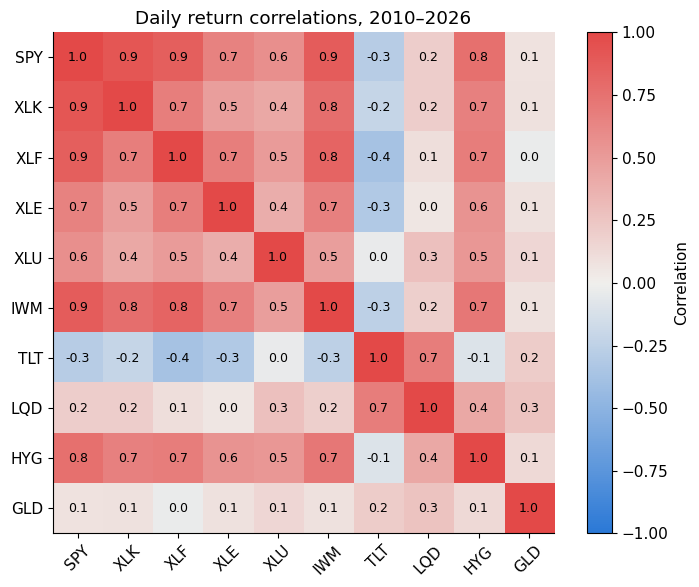

In [2]:
etfs = ["SPY", "XLK", "XLF", "XLE", "XLU", "IWM", "TLT", "LQD", "HYG", "GLD"]
corr = returns[etfs].corr()   # rho_ij for every pair

fig, ax = plt.subplots(figsize=(7.5, 6))
im = ax.imshow(corr, cmap=DIVERGING, vmin=-1, vmax=1)
ax.set_xticks(range(len(etfs)), etfs, rotation=45)
ax.set_yticks(range(len(etfs)), etfs)
ax.grid(False)
for i in range(len(etfs)):          # print each correlation in its cell
    for j in range(len(etfs)):
        ax.text(j, i, f"{round(corr.iloc[i, j], 1) + 0:.1f}", ha="center", va="center", fontsize=9)  # "+ 0" turns -0.0 into 0.0
fig.colorbar(im, ax=ax, label="Correlation")
ax.set_title("Daily return correlations, 2010–2026")
plt.tight_layout()
plt.show()

Three groups appear:

- **Equities** (SPY, the sector funds, small caps IWM) are all strongly positively correlated, mostly 0.5–0.9. They share the market factor. Utilities (XLU) and energy (XLE) are the least tied to the rest.
- **Treasuries** (TLT) are *negatively* correlated with equities over this period. On average, bonds rose when stocks fell. That is what makes them a hedge.
- **Credit** sits in between. High-yield bonds (HYG) behave a lot like stocks (0.8 with SPY), because they are loans to riskier companies. Investment-grade bonds (LQD) behave more like Treasuries. **Gold** (GLD) is close to uncorrelated with everything.

### 4.3 The two-asset formula in action

We mix SPY and TLT in every proportion from 0% to 100% stocks, and compute the portfolio volatility from $\sigma_p^2 = w_1^2\sigma_1^2 + w_2^2\sigma_2^2 + 2w_1w_2\rho\sigma_1\sigma_2$. The dashed line shows what volatility *would* be if the two were perfectly correlated ($\rho = 1$), which is just the weighted average.

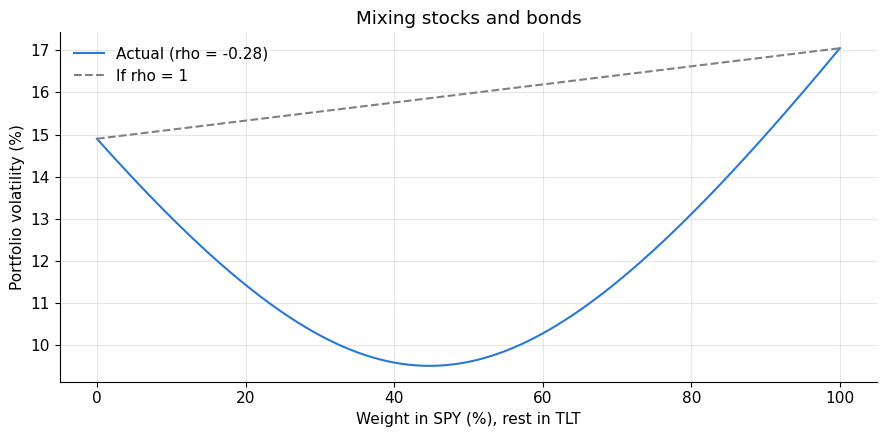

Lowest-volatility mix: 45% SPY / 55% TLT, volatility 9.5% vs 17.0% (SPY) and 14.9% (TLT)


In [3]:
s1, s2 = returns["SPY"].std() * np.sqrt(252), returns["TLT"].std() * np.sqrt(252)
rho = returns["SPY"].corr(returns["TLT"])
w1 = np.linspace(0, 1, 101)   # weight in SPY; the rest goes to TLT
w2 = 1 - w1

vol_actual = np.sqrt(w1**2 * s1**2 + w2**2 * s2**2 + 2 * w1 * w2 * rho * s1 * s2)
vol_no_div = w1 * s1 + w2 * s2   # rho = 1: no diversification benefit

fig, ax = plt.subplots()
ax.plot(w1 * 100, vol_actual * 100, label=f"Actual (rho = {rho:.2f})")
ax.plot(w1 * 100, vol_no_div * 100, "--", color="grey", label="If rho = 1")
ax.set_xlabel("Weight in SPY (%), rest in TLT")
ax.set_ylabel("Portfolio volatility (%)")
ax.set_title("Mixing stocks and bonds")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

best = w1[vol_actual.argmin()]
print(f"Lowest-volatility mix: {best:.0%} SPY / {1 - best:.0%} TLT, "
      f"volatility {vol_actual.min():.1%} vs {s1:.1%} (SPY) and {s2:.1%} (TLT)")

The solid curve dips well below the dashed line. A mix of roughly half stocks and half bonds had about 9.5% volatility, *lower than either asset on its own* (17% and 15%). That is the $2w_1w_2\rho\sigma_1\sigma_2$ term at work: with $\rho < 0$ it subtracts risk.

### 4.4 How many stocks do you need?

We check the $N \to \infty$ formula on our 43 stocks. For each $N$ we pick 200 random equal-weight portfolios of $N$ stocks, measure their volatility, and average. The dashed line is the theoretical floor $\sqrt{\overline{\text{cov}}}$.

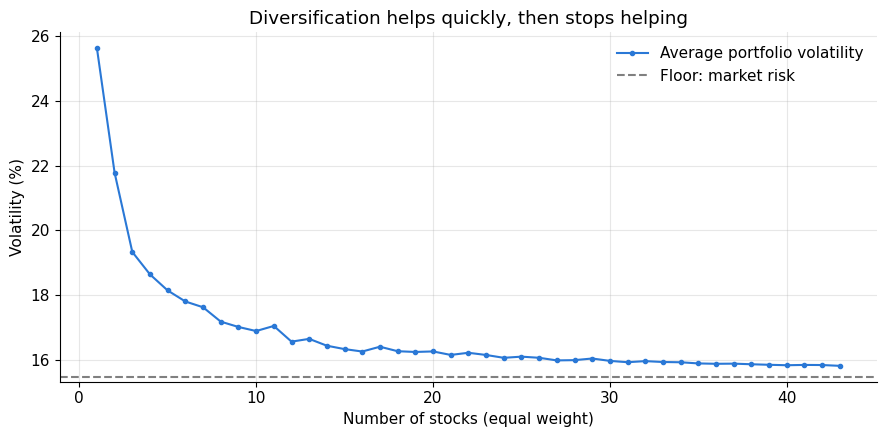

N =  1: 25.6%
N =  5: 18.2%
N = 10: 16.9%
N = 20: 16.3%
N = 43: 15.8%
Floor:  15.5%


In [4]:
stocks = meta.loc[meta.asset_type == "stock", "ticker"].tolist()
cov = returns[stocks].cov() * 252                     # annualised covariance matrix Sigma
rng = np.random.default_rng(0)                         # fixed seed: same result every run

sizes = range(1, len(stocks) + 1)
avg_vol = []
for n in sizes:
    vols = []
    for _ in range(200):
        pick = rng.choice(stocks, size=n, replace=False)
        w = np.full(n, 1 / n)                          # equal weights
        sub = cov.loc[pick, pick].values
        vols.append(np.sqrt(w @ sub @ w))              # sigma_p = sqrt(w' Sigma w)
    avg_vol.append(np.mean(vols))

off_diag = cov.values[~np.eye(len(stocks), dtype=bool)]
floor = np.sqrt(off_diag.mean())                       # sqrt(average covariance)

fig, ax = plt.subplots()
ax.plot(list(sizes), np.array(avg_vol) * 100, marker="o", markersize=3, label="Average portfolio volatility")
ax.axhline(floor * 100, ls="--", color="grey", label="Floor: market risk")
ax.set_xlabel("Number of stocks (equal weight)")
ax.set_ylabel("Volatility (%)")
ax.set_title("Diversification helps quickly, then stops helping")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

for n in [1, 5, 10, 20, 43]:
    print(f"N = {n:>2}: {avg_vol[n - 1]:.1%}")
print(f"Floor:  {floor:.1%}")

The curve falls steeply at first. Going from 1 to 10 stocks cuts volatility from about 26% to 17%. After that, adding stocks barely helps: 43 stocks give 15.8%, almost exactly the theoretical floor of 15.5%. That floor is the market risk all these stocks share, and no number of extra stocks removes it.

### 4.5 Correlations change

A single correlation over 16 years hides a lot. Here is the rolling 1-year correlation between stocks (SPY) and bonds (TLT).

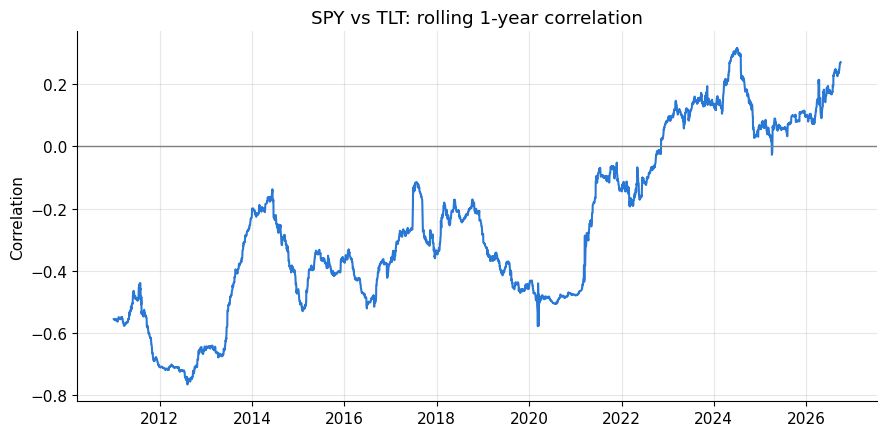

In [5]:
roll_corr = returns["SPY"].rolling(252).corr(returns["TLT"])

fig, ax = plt.subplots()
ax.plot(roll_corr.index, roll_corr, color=COLORS[0])
ax.axhline(0, color="grey", linewidth=1)
ax.set_ylabel("Correlation")
ax.set_title("SPY vs TLT: rolling 1-year correlation")
plt.tight_layout()
plt.show()

For most of the 2010s the stock–bond correlation was clearly negative, often around −0.4 or lower, which made a stock/bond mix very effective. In 2021–2022 that changed. Inflation pushed interest rates up, which hurt stocks *and* bonds at the same time. The correlation turned positive and has stayed around zero or above since. A portfolio built on the assumption "bonds always hedge stocks" lost on both sides in 2022.

## 5. Takeaways and where it breaks

- **Portfolio risk is $w^\top\Sigma w$**, not the average of the individual risks. Correlation is what makes the difference.
- **Diversification across stocks has a floor.** Beyond about 20 stocks you are mostly holding the market. To lower risk further you need *different* assets (bonds, gold), not *more* stocks.
- **Correlations are not stable.** They change with the economic regime and tend to rise in crises, exactly when you need diversification most.
- **Correlation only captures linear, average co-movement.** Two assets can have low correlation on normal days and still crash together on the worst days.
- **Estimation error.** With 43 stocks, $\Sigma$ has 946 distinct entries to estimate. Errors in $\Sigma$ become a major problem in portfolio optimisation (PR2).

**What you could build:** a dashboard that tracks rolling correlations between the club's holdings and flags when a "diversified" portfolio has quietly become one big bet.